In [17]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv2
def normalizar_imagem(img):
    if (img.max()<=1):
        img *= 255
    img = img.astype(np.uint8)
    return img

#Linha a ser trocada para teste é abaixo
img_teste = normalizar_imagem(plt.imread('baboon_monocromatica.png'))

def escolha_imagem(original):
    opcao = int(input("1 - Imagem de teste original\n2 - Imagem de teste escolhida\n"))
    img = None
    if opcao == 1:
        img = original.copy()
    elif opcao == 2:
        img = img_teste.copy()
    else:
        print("Opção inválida, imagem original usada")
        img = original.copy()

    return img

def plotar_imagem(img,img_modificada, titulo):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    im1 = ax[0].imshow(img, cmap='gray')
    ax[0].set_title('Imagem Original')

    im2 = ax[1].imshow(img_modificada, cmap='gray')
    ax[1].set_title(titulo)

    plt.show()
    
def plotar_histograma(img, titulo):
    plt.figure(figsize=(8, 4))
    plt.hist(img.ravel(), bins=256, range=(0, 256), color='gray')
    plt.title('Histograma da Imagem - ' + titulo)
    plt.xlabel('Intensidade de Pixels')
    plt.ylabel('Frequência')
    plt.show()

def calcular_fracao_pretos(img):
    # Conta quantos pixels são iguais a 0
    pixels_pretos = np.sum(img == 0)
    
    # Calcula o total de pixels (largura x altura)
    total_pixels = img.size
    
    fracao = pixels_pretos / total_pixels
    
    print(f"Total de pixels: {total_pixels}")
    print(f"Pixels pretos: {pixels_pretos}")
    print(f"Fração de pretos: {fracao:.4f} ({fracao*100:.2f}%)")
    
    return fracao


In [4]:
baboon_mono = normalizar_imagem(plt.imread('baboon_monocromatica.png'))
house = normalizar_imagem(plt.imread('house.png'))
butterfly = normalizar_imagem(plt.imread('butterfly.png'))

## **Métodos de Limiarização Globais**

**Método Global**

Total de pixels: 262144
Pixels pretos: 34084
Fração de pretos: 0.1300 (13.00%)


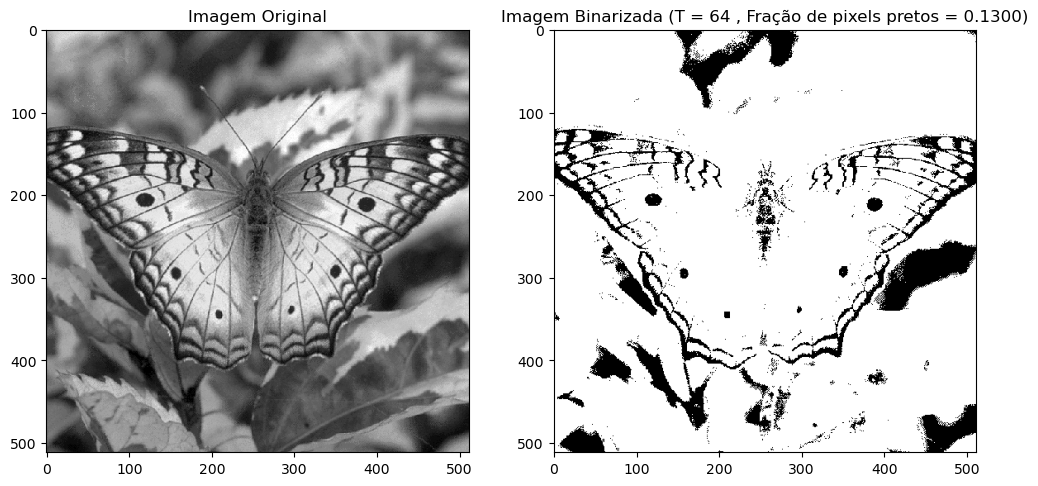

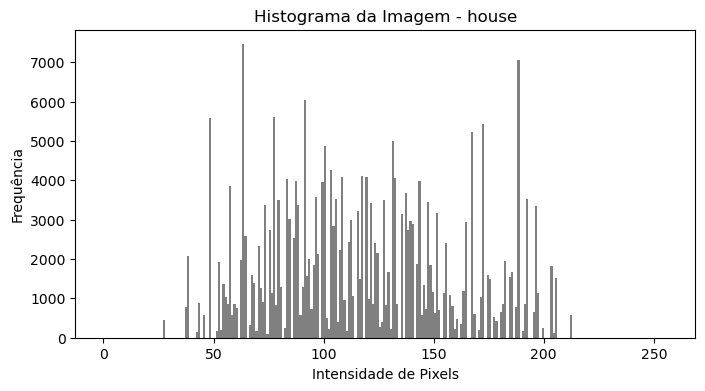

In [ ]:
img = escolha_imagem(butterfly)

T = int(input("Limiar de Binzarização (Valor de 0 a 255): "))

img = normalizar_imagem(img)

img_modificada = img.copy()

#Binarização das imagens
img_modificada[img_modificada>T] = 255
img_modificada[img_modificada<=T] = 0

plotar_imagem(img, img_modificada, f'Imagem Binarizada (T = {T} , Fração de pixels pretos = {calcular_fracao_pretos(img_modificada):.4f})')

**Método de Otsu**

Total de pixels: 262144
Pixels pretos: 125196
Fração de pretos: 0.4776 (47.76%)


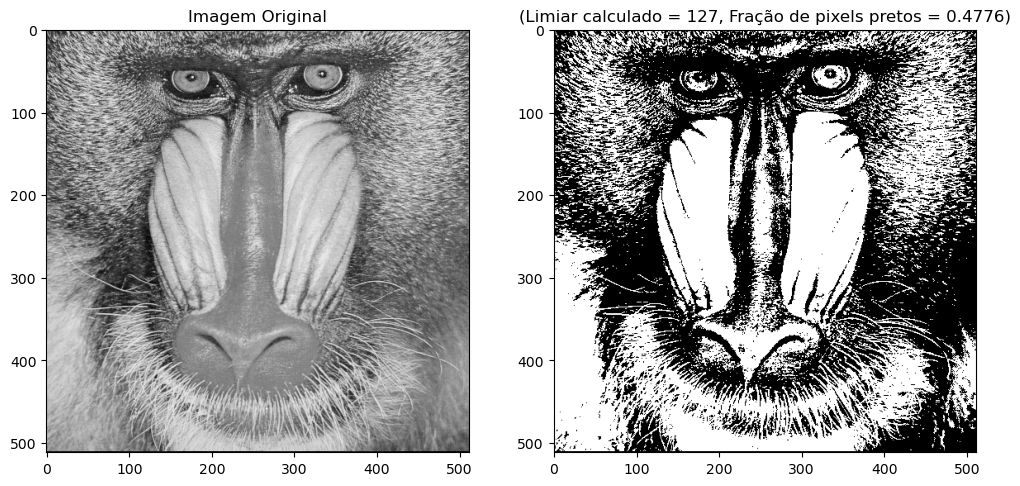

In [ ]:
img = escolha_imagem(baboon_mono)

img_modificada = img.copy()

#Método de Otsu
ret, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_OTSU)

plotar_imagem(img, thresh, f'(Limiar calculado = {int(ret)}, Fração de pixels pretos = {calcular_fracao_pretos(thresh):.4f})')

## **Métodos de Limiarização Local**

**Método de Bernsen**

In [ ]:
img = escolha_imagem(baboon_mono)

img_modificada = img.copy()

#Método de Otsu
ret, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_OTSU)

plotar_imagem(img, thresh, f'(Limiar calculado = {int(ret)}, Fração de pixels pretos = {calcular_fracao_pretos(thresh):.4f})')